# <center>EDA</center>

In [51]:
# Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [52]:
# Loading the cleaned dataset
df = pd.read_csv('data/cleaned_data.csv')

In [53]:
# Checking the shape
df.shape

(10000, 9)

In [54]:
# Checking the first 5 rows
df.head()

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [55]:
# Separating the num and cat columns
# Removing target from numerical cols lists
num_cols = df.select_dtypes(include='number').columns.drop('target')

# Removing product_id from cat cols because it is an identifier
cat_cols = df.select_dtypes(exclude='number').columns.drop('product_id')

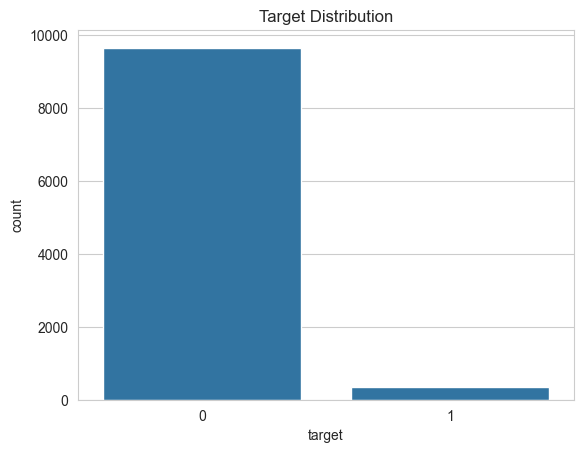

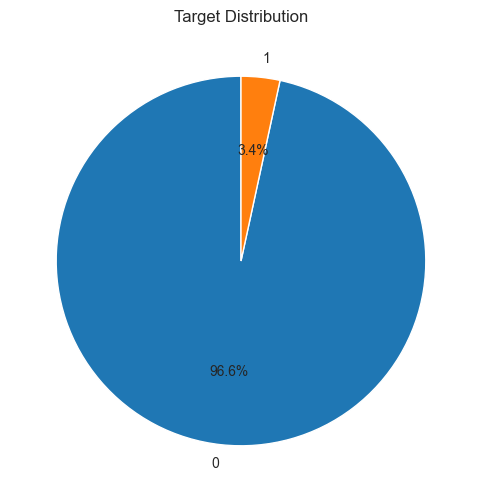

target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [56]:
# Checking the distribution of target variable
sns.countplot(x=df["target"], data=df)
plt.title('Target Distribution')
plt.show()

# Pie chart
count = df['target'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(count.values, labels=count.index, autopct='%1.1f%%', startangle=90)
plt.title(f'Target Distribution')
plt.show()

# value_counts
df['target'].value_counts(normalize=True)

### Insights:

- Clearly its a class imbalance issue, the machines failed only approx 3.4% of the total
- The dataset is highly imbalanced
- The model may become biased toward predicting the majority class
- Evaluation metrics like accuracy alone may not be sufficient
- Additional metrics like precision, recall, and F1-score should be considered

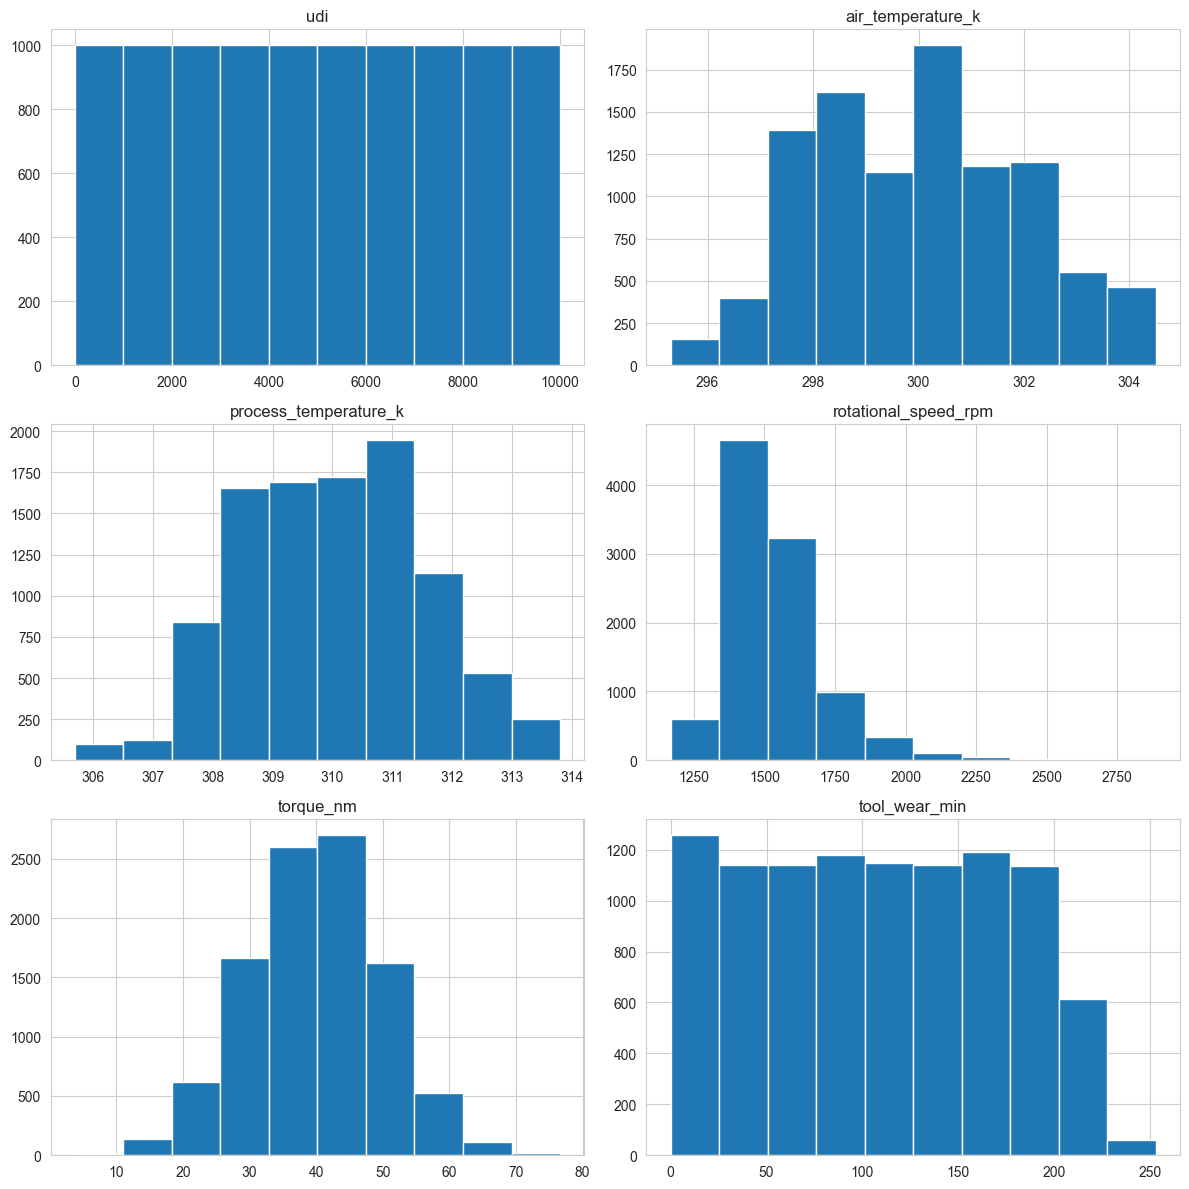

In [57]:
# Checking the distribution of numerical columns
df[num_cols].hist(figsize=(12,12))
plt.tight_layout()
plt.show()

### Insights
- UDI shows a uniform distribution as it is a sequential identifier and does not carry any predictive information So will drop it.
- Air temperature is approximately normally distributed with low variance, indicating stable operating conditions.
- Process temperature follows a near-normal distribution with slightly higher central tendency compared to air temperature.
- Rotational speed is right-skewed, indicating presence of high-speed operational cases which may be linked to machine stress.
- Torque shows a near-normal distribution, suggesting consistent operational behavior across machines.
- Tool wear is evenly distributed across its range, indicating continuous usage progression of machines.

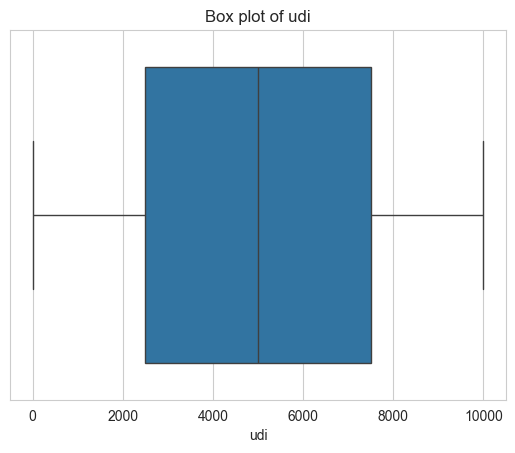

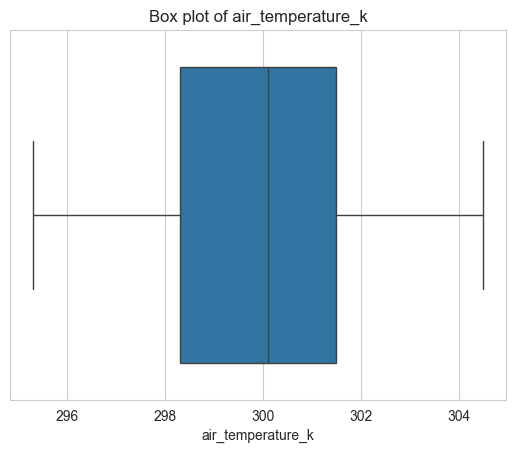

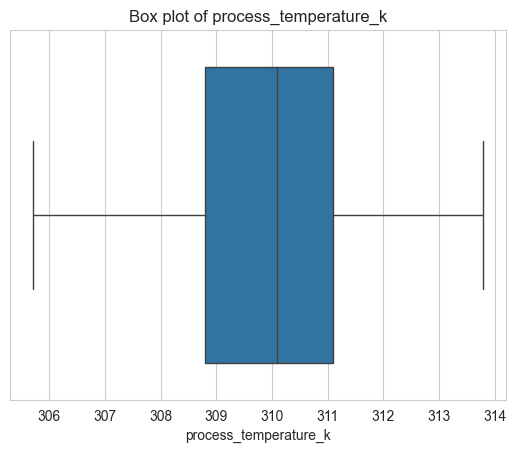

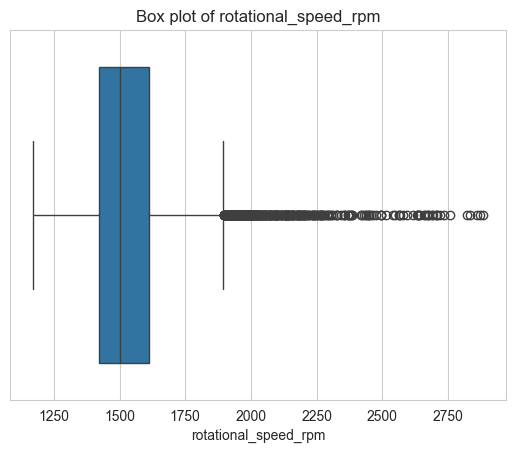

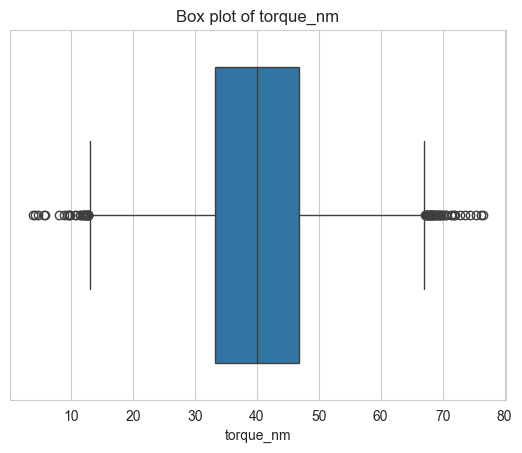

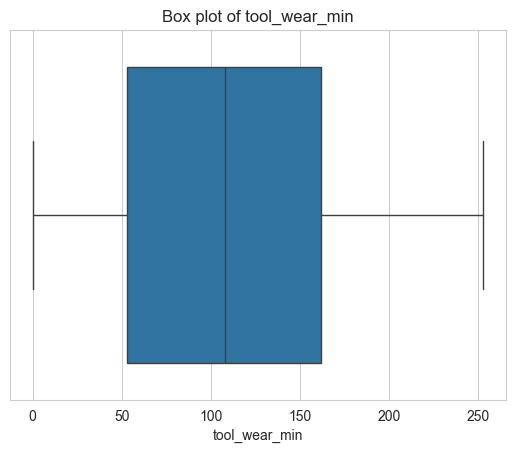

In [58]:
# Checking for the outliers using box plot
for cols in num_cols:
    sns.boxplot(x=cols, data=df)
    plt.title(f"Box plot of {cols}")
    plt.show()

In [59]:
# Outlier Summary

def outlier_summary_all(df):
    summaries = []
    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        summaries.append({
            "column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outliers.shape[0],
            "outlier_percentage": outliers.shape[0] / df.shape[0] * 100
        })
    
    return pd.DataFrame(summaries)

outlier_summary_all(df)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,udi,2500.75,7500.25,4999.5,-4998.50,14999.50,0,0.00
1,air_temperature_k,298.30,301.50,3.2,293.50,306.30,0,0.00
2,process_temperature_k,308.80,311.10,2.3,305.35,314.55,0,0.00
3,rotational_speed_rpm,1423.00,1612.00,189.0,1139.50,1895.50,418,4.18
4,torque_nm,33.20,46.80,13.6,12.80,67.20,69,0.69
5,tool_wear_min,53.00,162.00,109.0,-110.50,325.50,0,0.00
6,target,0.00,0.00,0.0,0.00,0.00,339,3.39


### Insights
- The dataset shows minimal presence of outliers across most features, indicating stable data quality. Rotational speed is the only feature with a noticeable proportion of outliers, likely representing extreme operational conditions. Since this is a predictive maintenance problem, such outliers may carry important information related to machine failure and are retained for further analysis.

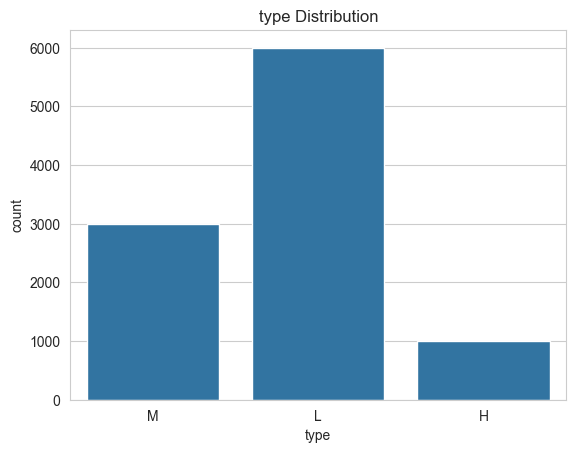

In [60]:
# Checking the distribution of categorical columns
for col in cat_cols:
    sns.countplot(x=df[col], data=df)
    plt.title(f'{col} Distribution')
    plt.show()

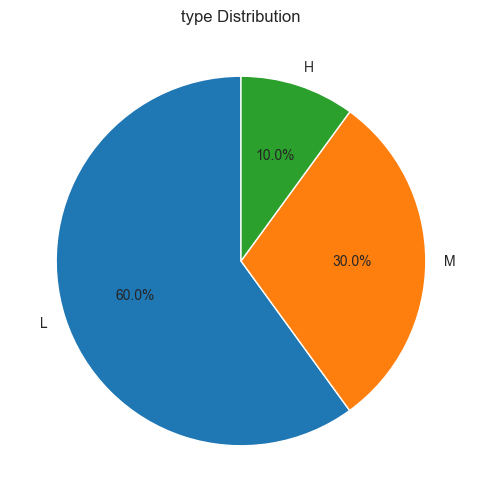

In [61]:
# Checking the distribution of Categorical using pie chart
for col in cat_cols:
    count = df[col].value_counts()

    plt.figure(figsize=(6,6))
    plt.pie(count.values, labels=count.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'{col} Distribution')
    plt.show()

In [62]:
# Checking the cross tabulation between type and target
# Is Failure rate change by type
pd.crosstab(df['type'], df['target'], normalize='index')

target,0,1
type,,
H,0.979063,0.020937
L,0.960833,0.039167
M,0.972306,0.027694


### Insights
- The failure rate varies across product types, with type L showing the highest failure rate (~3.9%) and type H the lowest (~2.1%). Although the difference is not very large, it indicates that the type feature has some influence on machine failure and should be retained for modeling.

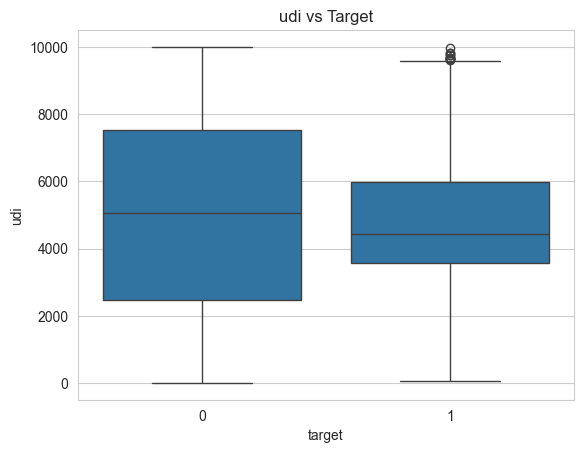

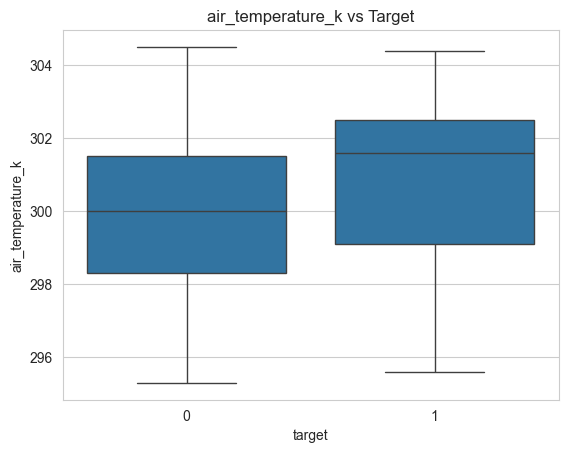

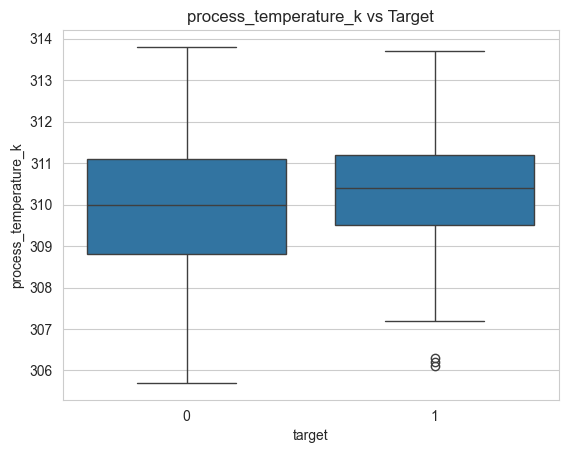

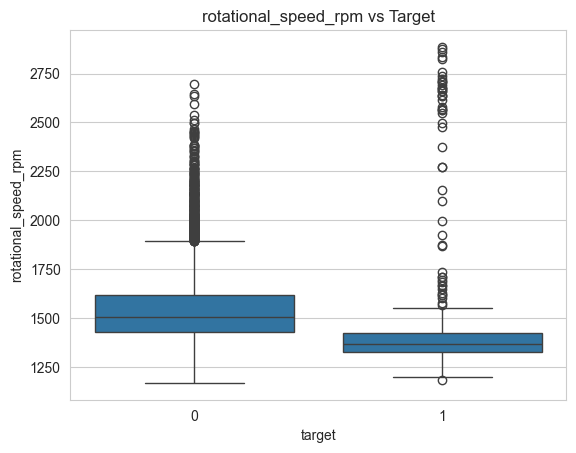

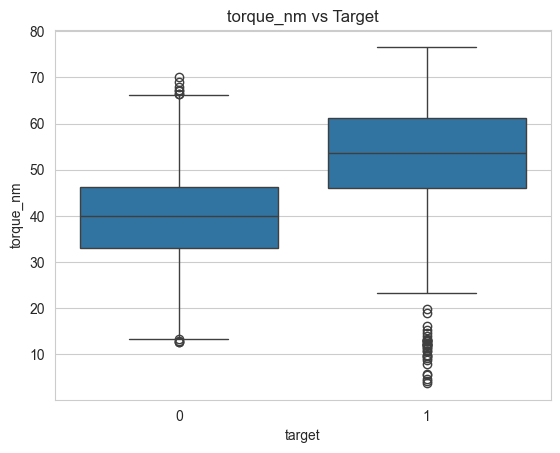

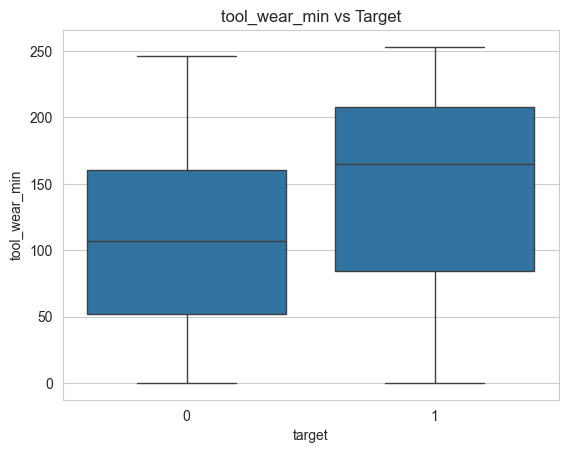

In [63]:
# Numerical columns Vs Target
for col in num_cols:
    plt.figure()
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

### Insights

Target = 1 is characterized by:
- Higher torque
- Lower rotational speed
- Greater tool wear
- Slightly higher process and air temperatures

Target = 0 is characterized by:
- Lower torque
- Higher rotational speed (with more variability)
- Lower tool wear
- Slightly cooler process and air temperatures

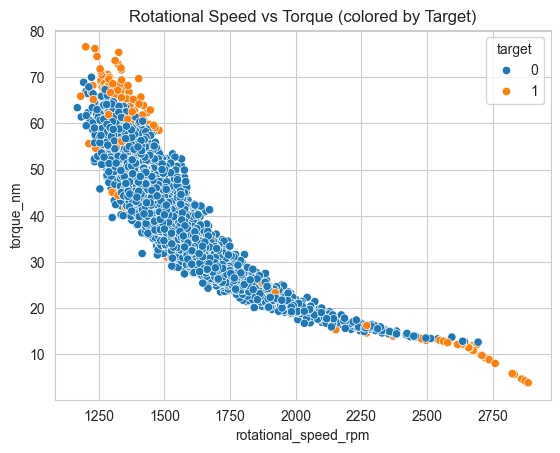

In [64]:
# Plotting scatter plot for Rotational Speed vs Torque with respect to Target
sns.scatterplot(x='rotational_speed_rpm', y='torque_nm', hue='target', data=df)
plt.title("Rotational Speed vs Torque (colored by Target)")
plt.show()

### Insights
- From the scatter plot, I observed a strong inverse relationship between rotational speed and torque. Machine failures are more concentrated in high torque and low speed regions, indicating that failures are driven by high load conditions rather than individual features. This highlights the importance of feature interaction in predictive maintenance models.

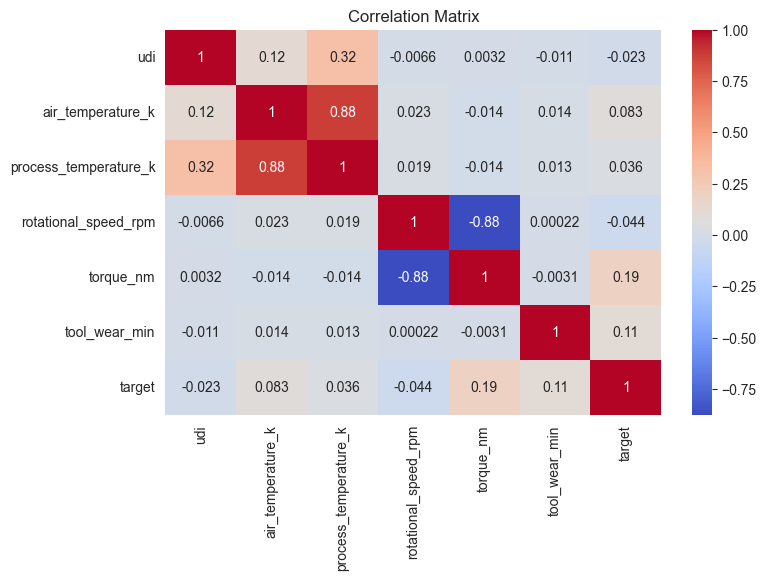

In [65]:
# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Insights
- The correlation analysis shows that torque_nm has the highest positive correlation (0.19) with machine failure, making it the most influential feature among the available variables.
- tool_wear_min also shows a moderate positive correlation (0.10), indicating that increased tool wear contributes to a higher likelihood of failure.
- air_temperature_k and process_temperature_k have very weak correlations with the target, suggesting they are not strong individual predictors of failure.
- rotational_speed_rpm shows almost no direct correlation (-0.04) with failure, implying that its impact is not linear.
- A strong negative correlation (-0.87) exists between rotational_speed_rpm and torque_nm, indicating an inverse relationship between these two features.
- Overall, the low correlation values with the target suggest that machine failure is not driven by a single feature but rather by complex interactions between multiple features.

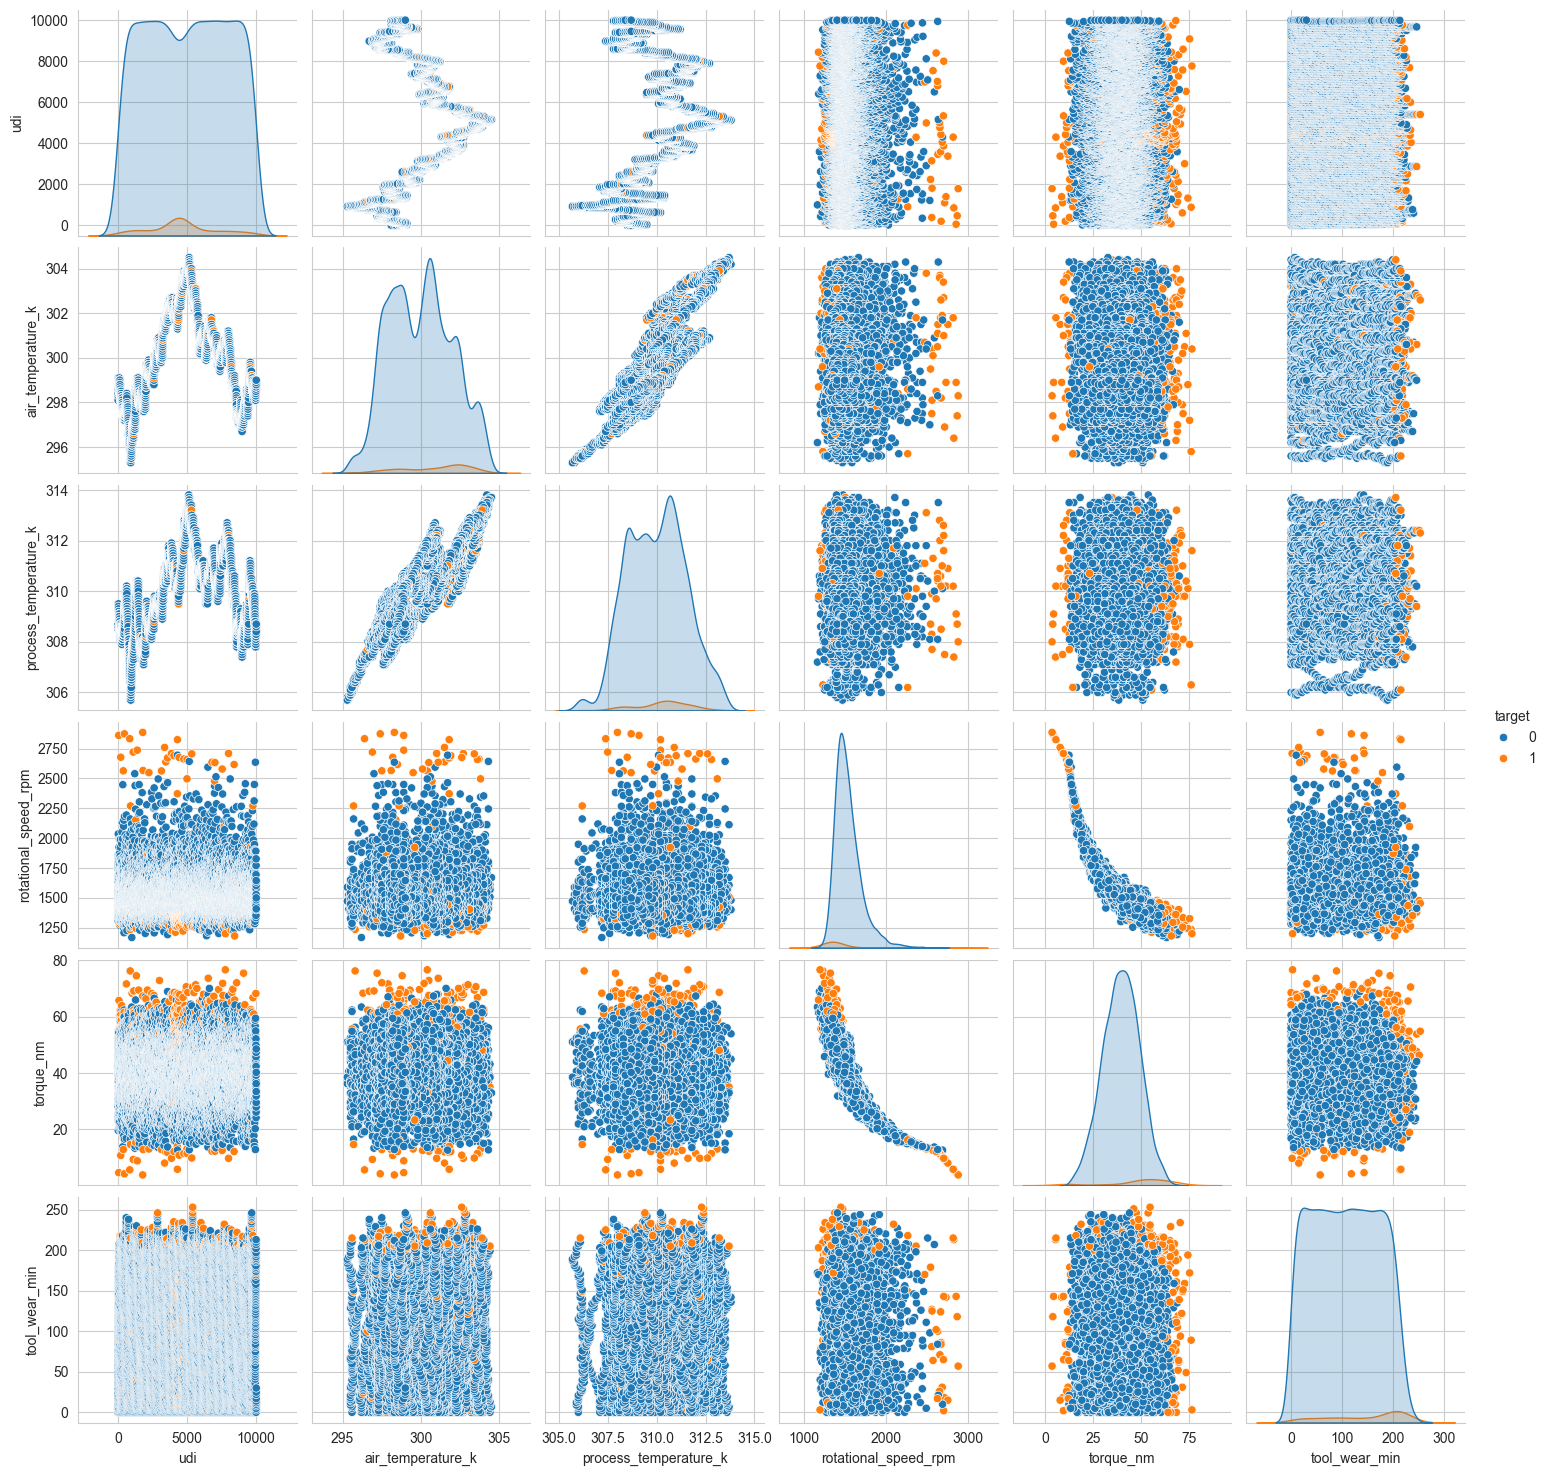

In [66]:
# Checking the pairplot with target
sns.pairplot(df, hue='target')
plt.show()

### Insights
- The pairplot reveals a strong positive relationship between air temperature and process temperature, indicating multicollinearity and redundancy in temperature-related features.
- A strong inverse (non-linear) relationship between rotational speed and torque is clearly visible, suggesting that these features are interdependent and represent machine operating conditions.
- Failure cases (target = 1) are not randomly distributed and tend to appear more frequently in regions of high torque and extreme rotational speeds, highlighting the importance of feature interaction.
- Individual features show significant overlap between failure and non-failure classes, indicating that no single feature can effectively separate the target variable.
- Tool wear shows a slight upward trend with failure cases, suggesting that increased wear contributes to failure, but it is not a dominant factor alone.
- The overall distribution patterns suggest that machine failure is driven by complex, non-linear relationships rather than simple linear dependencies.

In [67]:
# Creating one New column i.e. 'Temp_diff' using process and air temp
df['temp_diff'] = df['process_temperature_k'] - df['air_temperature_k']

In [68]:
# Creating a new feature i.e. 'power_kw'
df['power_kw'] = (df['torque_nm'] * (2 * np.pi * df['rotational_speed_rpm'] / 60)) / 1000


In [69]:
# Checking the correlation
df[['power_kw','temp_diff', 'target']].corr()

,power_kw,temp_diff,target
power_kw,1.000000,0.006694,0.176039
temp_diff,0.006694,1.000000,-0.111676
target,0.176039,-0.111676,1.000000


### Insights
- After feature engineering, I found that power (derived from torque and rotational speed) had a stronger correlation with machine failure than the original features, indicating that combined operational load is a better predictor than individual variables.

In [70]:
# Droping the Identifier columns i.e. 'product_id', 'udi'
df = df.drop(columns=['product_id', 'udi'], axis=1)

In [71]:
# Checking the first five rows of final df
df.head()

,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,temp_diff,power_kw
0,M,298.1,308.6,1551,42.8,0,0,10.5,6.951591
1,L,298.2,308.7,1408,46.3,3,0,10.5,6.826723
2,L,298.1,308.5,1498,49.4,5,0,10.4,7.749388
3,L,298.2,308.6,1433,39.5,7,0,10.4,5.927505
4,L,298.2,308.7,1408,40.0,9,0,10.5,5.897817


In [72]:
# Saving the new dataset
df.to_csv("data/final_data.csv", index=False)